# 03. 이미지 전처리 + 데이터 증강
- dataset_cleaned.csv 불러오기
- 베이스라인용 Generator (정규화만)
- Train용 ImageDataGenerator (전처리 + 증강)
- Val/Test용 ImageDataGenerator (전처리만)
- 증강 샘플 시각화
- augmentation_log.csv 저장

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 경로 설정 및 데이터 로드

In [2]:
ROOT      = Path('..')
PROCESSED = ROOT / 'data/processed'
FIG_DIR   = ROOT / 'outputs/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# 02_eda에서 생성한 정제 CSV 불러오기
df = pd.read_csv(PROCESSED / 'dataset_cleaned.csv')

# sub_img_path 우선 사용, 없으면 img_path 사용
target_col = 'sub_img_path' if 'sub_img_path' in df.columns else 'img_path'

# split별 분리
df_train = df[df['split'] == 'train'].copy()
df_val   = df[df['split'] == 'val'].copy()
df_test  = df[df['split'] == 'test'].copy()

print(f'데이터 로드 완료')
print(f'  train : {len(df_train):,}장')
print(f'  val   : {len(df_val):,}장')
print(f'  test  : {len(df_test):,}장')

데이터 로드 완료
  train : 24,492장
  val   : 5,249장
  test  : 5,246장


## 2. 정규화 설정
02_eda에서 계산한 채널별 mean/std 사용

In [3]:
# 02_eda에서 계산한 정규화 기준값
MEAN = [0.5616, 0.5263, 0.5056]  # R, G, B 채널 평균
STD  = [0.1819, 0.1841, 0.1837]  # R, G, B 채널 표준편차
IMG_SIZE   = (224, 224)          # CNN 입력 크기
BATCH_SIZE = 32

print(f'정규화 mean : {MEAN}')
print(f'정규화 std  : {STD}')
print(f'입력 크기   : {IMG_SIZE}')
print(f'배치 크기   : {BATCH_SIZE}')

정규화 mean : [0.5616, 0.5263, 0.5056]
정규화 std  : [0.1819, 0.1841, 0.1837]
입력 크기   : (224, 224)
배치 크기   : 32


## 3. class_weight 계산 (축종 불균형 보정)
반려견/반려묘 데이터 수 차이를 모델 학습 시 가중치로 보정

In [5]:
# 축종별 불균형 확인
print('[축종별 train 데이터 수]')
print(df_train['species'].value_counts())

# class_weight 계산 → 수가 적은 반려묘에 높은 가중치 부여
species_classes = df_train['species'].unique().to_numpy()
species_weights = compute_class_weight(
    class_weight='balanced',
    classes=species_classes,
    y=df_train['species']
)
species_weight_dict = dict(zip(species_classes, species_weights))
print(f'\n축종별 class_weight: {species_weight_dict}')
print('\n※ 이 값을 04_modeling.ipynb의 model.fit()에 전달하세요.')

[축종별 train 데이터 수]
species
D    21736
C     2756
Name: count, dtype: int64

축종별 class_weight: {'D': np.float64(0.5633971291866029), 'C': np.float64(4.443396226415095)}

※ 이 값을 04_modeling.ipynb의 model.fit()에 전달하세요.


## 4. ImageDataGenerator 정의

### 실험 버전 안내
| 버전 | Train Generator | 용도 |
|------|----------------|------|
| 실험 1 | `baseline_datagen` | 증강 없음 (베이스라인) |
| 실험 2 | `train_datagen` | 증강 적용 |
| 실험 3 | `train_datagen` + `class_weight` | 증강 + 불균형 보정 |

In [6]:
# ── 실험 1용: 베이스라인 (정규화만) ──
baseline_datagen = ImageDataGenerator(
    rescale=1./255   # 픽셀값 0~255 → 0~1 정규화만 적용
)

# ── 실험 2, 3용: 전처리 + 증강 ──
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # 픽셀값 0~255 → 0~1 정규화
    horizontal_flip=True,            # 좌우 반전 (피부 병변은 방향 무관)
    rotation_range=30,               # ±30도 회전 (카메라 각도 다양성)
    brightness_range=[0.8, 1.2],     # 밝기 조정 (촬영 환경 차이 극복)
    zoom_range=0.1,                  # 10% 확대/축소 (병변 크기 다양성)
    width_shift_range=0.1,           # 가로 이동 (병변 위치 다양성)
    height_shift_range=0.1,          # 세로 이동 (병변 위치 다양성)
    fill_mode='nearest'              # 빈 영역을 nearest 픽셀로 채움
    # vertical_flip 미적용: 몸통/다리 부위는 방향이 의미 있을 수 있음
    # shear/channel_shift 미적용: 피부색 왜곡으로 병변 특징 손실 위험
)

# ── Val/Test용: 정규화만 (증강 X → 평가 결과 왜곡 방지) ──
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print('ImageDataGenerator 정의 완료')

ImageDataGenerator 정의 완료


## 5. DataFrame 기반 Generator 생성

In [7]:
# ── 실험 1: 베이스라인 Generator ──
baseline_train_generator = baseline_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# ── 실험 2, 3: 증강 적용 Generator ──
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

# ── Val/Test Generator (공통) ──
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False           # Val/Test는 순서 유지
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col=target_col,
    y_col='lesion',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\n클래스 인덱스: {train_generator.class_indices}')

Found 24492 validated image filenames belonging to 7 classes.
Found 24492 validated image filenames belonging to 7 classes.
Found 5249 validated image filenames belonging to 7 classes.
Found 5246 validated image filenames belonging to 7 classes.

클래스 인덱스: {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}


## 6. 증강 샘플 시각화
같은 이미지에 증강을 적용했을 때 어떻게 변하는지 확인

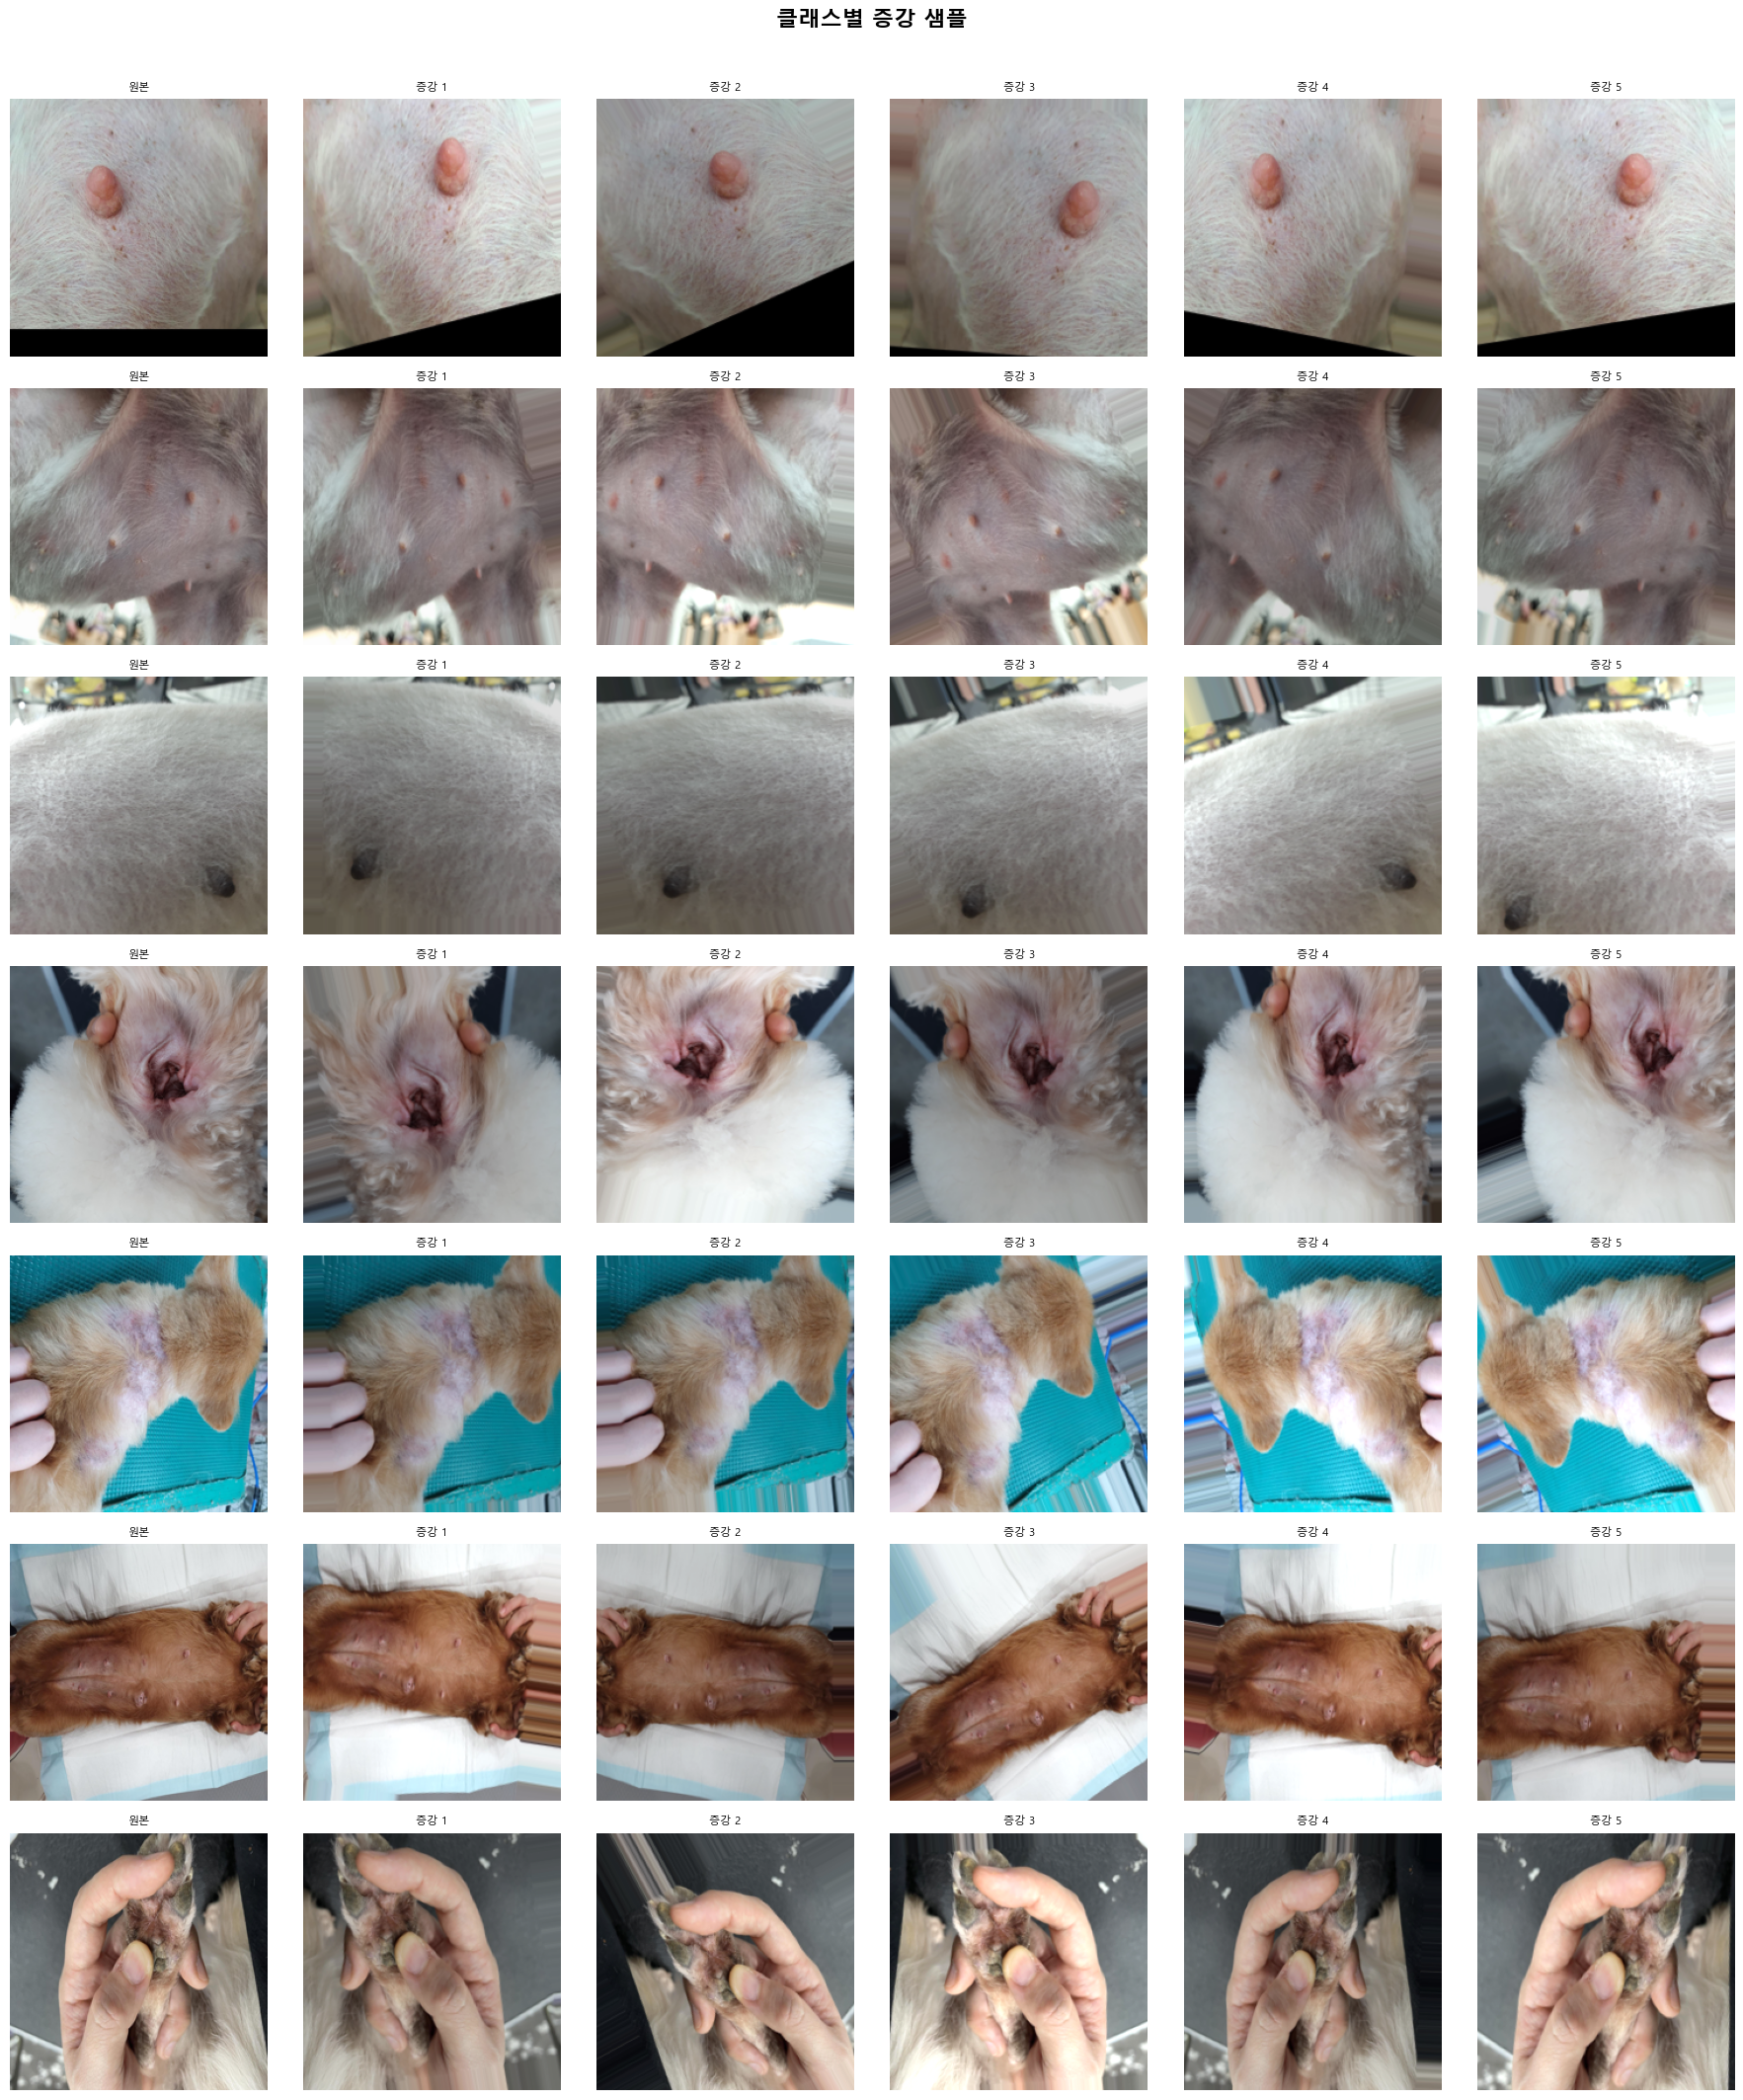

저장 완료 → outputs/figures/augmentation_samples.png


In [8]:
LESION_MAP = {
    'A1': 'A1 구진/플라크', 'A2': 'A2 비듬/각질', 'A3': 'A3 태선화/색소',
    'A4': 'A4 농포/여드름', 'A5': 'A5 미란/궤양', 'A6': 'A6 결절/종괴',
    'A7': 'A7 무증상(정상)'
}

def show_augmentation_samples(df, target_col, datagen, n_augments=5):
    """클래스별 원본 1장 + 증강 n장을 격자로 시각화."""
    classes = sorted(df['lesion'].unique())
    fig, axes = plt.subplots(len(classes), n_augments + 1,
                             figsize=((n_augments + 1) * 3, len(classes) * 3))

    for row_idx, cls in enumerate(classes):
        sample_path = df[df['lesion'] == cls].iloc[0][target_col]
        img = Image.open(sample_path).resize((224, 224)).convert('RGB')
        img_arr = np.array(img)

        # 원본 이미지
        axes[row_idx][0].imshow(img_arr)
        axes[row_idx][0].set_title('원본', fontsize=8)
        axes[row_idx][0].axis('off')
        axes[row_idx][0].set_ylabel(LESION_MAP.get(cls, cls), fontsize=8,
                                    rotation=0, labelpad=80, va='center')

        # 증강 이미지 n장
        img_expanded = np.expand_dims(img_arr, axis=0)
        aug_iter = datagen.flow(img_expanded, batch_size=1)
        for col_idx in range(1, n_augments + 1):
            aug_img = np.clip(next(aug_iter)[0].astype('float32'), 0, 1)
            axes[row_idx][col_idx].imshow(aug_img)
            axes[row_idx][col_idx].set_title(f'증강 {col_idx}', fontsize=8)
            axes[row_idx][col_idx].axis('off')

    plt.suptitle('클래스별 증강 샘플', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'augmentation_samples.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('저장 완료 → outputs/figures/augmentation_samples.png')

show_augmentation_samples(df_train, target_col, train_datagen)

## 7. augmentation_log.csv 저장

In [9]:
aug_log = pd.DataFrame([
    {'기법': 'rescale',          '적용 대상': 'train/val/test', '설정값': '1./255',      '적용 이유': '픽셀값 0~255를 0~1로 정규화'},
    {'기법': 'horizontal_flip',  '적용 대상': 'train',          '설정값': 'True',        '적용 이유': '피부 병변은 좌우 방향 무관'},
    {'기법': 'rotation_range',   '적용 대상': 'train',          '설정값': '30',          '적용 이유': '카메라 각도 다양성 반영'},
    {'기법': 'brightness_range', '적용 대상': 'train',          '설정값': '[0.8, 1.2]',  '적용 이유': '촬영 환경(조명) 차이 극복'},
    {'기법': 'zoom_range',       '적용 대상': 'train',          '설정값': '0.1',         '적용 이유': '병변 크기 다양성 반영'},
    {'기법': 'width_shift',      '적용 대상': 'train',          '설정값': '0.1',         '적용 이유': '병변 위치 다양성 반영'},
    {'기법': 'height_shift',     '적용 대상': 'train',          '설정값': '0.1',         '적용 이유': '병변 위치 다양성 반영'},
    {'기법': 'vertical_flip',    '적용 대상': '미적용',          '설정값': '-',           '적용 이유': '몸통/다리 부위 상하 방향이 의미 있어 제외'},
    {'기법': 'shear/channel',    '적용 대상': '미적용',          '설정값': '-',           '적용 이유': '피부색 왜곡으로 병변 특징 손실 위험'},
    {'기법': 'class_weight',     '적용 대상': '실험 3',          '설정값': str(species_weight_dict), '적용 이유': '축종 간 데이터 불균형 보정'},
])

aug_log.to_csv(PROCESSED / 'augmentation_log.csv', index=False, encoding='utf-8-sig')
print('저장 완료 → data/processed/augmentation_log.csv')
aug_log

저장 완료 → data/processed/augmentation_log.csv


,기법,적용 대상,설정값,적용 이유
0,rescale,train/val/test,1./255,픽셀값 0~255를 0~1로 정규화
1,horizontal_flip,train,True,피부 병변은 좌우 방향 무관
2,rotation_range,train,30,카메라 각도 다양성 반영
3,brightness_range,train,"[0.8, 1.2]",촬영 환경(조명) 차이 극복
4,zoom_range,train,0.1,병변 크기 다양성 반영
5,width_shift,train,0.1,병변 위치 다양성 반영
6,height_shift,train,0.1,병변 위치 다양성 반영
7,vertical_flip,미적용,-,몸통/다리 부위 상하 방향이 의미 있어 제외
8,shear/channel,미적용,-,피부색 왜곡으로 병변 특징 손실 위험
9,class_weight,실험 3,"{'D': np.float64(0.5633971291866029), 'C': np....",축종 간 데이터 불균형 보정


## 8. 최종 요약 및 전달 사항

In [10]:
print('=' * 55)
print('전처리 + 증강 최종 요약')
print('=' * 55)
print(f'입력 이미지 크기       : {IMG_SIZE}')
print(f'정규화 mean (RGB)      : {MEAN}')
print(f'정규화 std  (RGB)      : {STD}')
print(f'배치 크기              : {BATCH_SIZE}')
print(f'클래스 수              : {len(train_generator.class_indices)}')
print(f'클래스 인덱스          : {train_generator.class_indices}')
print(f'축종 class_weight      : {species_weight_dict}')
print('=' * 55)
print('\n[전달할 것]')
print('  실험 1 → baseline_train_generator + val/test_generator')
print('  실험 2 → train_generator + val/test_generator')
print('  실험 3 → train_generator + val/test_generator + species_weight_dict')

전처리 + 증강 최종 요약
입력 이미지 크기       : (224, 224)
정규화 mean (RGB)      : [0.5616, 0.5263, 0.5056]
정규화 std  (RGB)      : [0.1819, 0.1841, 0.1837]
배치 크기              : 32
클래스 수              : 7
클래스 인덱스          : {'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'A6': 5, 'A7': 6}
축종 class_weight      : {'D': np.float64(0.5633971291866029), 'C': np.float64(4.443396226415095)}

[전달할 것]
  실험 1 → baseline_train_generator + val/test_generator
  실험 2 → train_generator + val/test_generator
  실험 3 → train_generator + val/test_generator + species_weight_dict
